<a href="https://colab.research.google.com/github/Sunidhi-Gautam/FL_Implementation/blob/main/Client_side_KD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sunidhigautam26","key":"df9c2dd0e0f5995bb0a2fd692c71ec16"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
# ================== IMPORTS ==================
import os
import random
import shutil
from glob import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from torchvision.models import MobileNet_V2_Weights
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
import json
import pandas as pd

# ================== DEVICE ==================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
# ================== DRIVE ROOT ==================
DRIVE_ROOT = "/content/drive/MyDrive/clients_datasets"
os.makedirs(DRIVE_ROOT, exist_ok=True)

In [6]:
# ================== TRANSFORMS ==================
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
# ================== DATASET DISTRIBUTION ==================
def view_distribution(base_dir, title):
    print(f"\n===== {title} =====\n")
    total_images = 0
    for split in ["train", "val", "test"]:
        split_dir = os.path.join(base_dir, split)
        if not os.path.exists(split_dir):
            print(f"{split.upper()} SET: NOT FOUND\n")
            continue

        print(f"{split.upper()} SET:")
        split_total = 0
        classes = sorted([
            d for d in os.listdir(split_dir)
            if os.path.isdir(os.path.join(split_dir, d))
        ])
        for cls in classes:
            count = len(glob(os.path.join(split_dir, cls, "*")))
            print(f"{cls:<40} {count}")
            split_total += count
            total_images += count
        print(f"Total images in {split}: {split_total}\n")
    print(f"TOTAL IMAGES OVERALL: {total_images}")

**Client 1 Dataset Download**

In [8]:
CLIENT1_DIR = f"{DRIVE_ROOT}/client_1"

if not os.path.exists(CLIENT1_DIR):
    print("Downloading Client 1 dataset...")

    !kaggle datasets download -d musfiqurtuhin/bangladeshi-crops-disease-dataset-bcdd -p /content/client1_raw_kd
    !unzip -q /content/client1_raw_kd/*.zip -d /content/client1_raw_kd

    RAW_DIR = "/content/client1_raw_kd/Bangladeshi_Crops_Disease_Dataset"

    # VIEW ORIGINAL DATASET
    view_distribution(RAW_DIR, "CLIENT 1 – ORIGINAL DATASET")

    splits = ["train", "val", "test"]

    for split in splits:
        os.makedirs(os.path.join(CLIENT1_DIR, split), exist_ok=True)
        split_dir = os.path.join(RAW_DIR, split)

        # EXPLICIT TOMATO FILTER
        tomato_classes = [
            d for d in os.listdir(split_dir)
            if "tomato" in d.lower()
        ]

        assert len(tomato_classes) > 0, "No tomato classes found!"

        for cls in tomato_classes:
            src = os.path.join(split_dir, cls)
            dst = os.path.join(CLIENT1_DIR, split, cls)
            os.makedirs(dst, exist_ok=True)

            for img in glob(os.path.join(src, "*")):
                shutil.copy(img, dst)

    print("Client 1 tomato-only dataset saved to Drive")

    # VIEW FINAL DATASET
    view_distribution(CLIENT1_DIR, "CLIENT 1 – TOMATO-ONLY (FINAL)")

else:
    print("Client 1 dataset already exists in Drive")
    view_distribution(CLIENT1_DIR, "CLIENT 1 – FROM DRIVE")

Dataset URL: https://www.kaggle.com/datasets/musfiqurtuhin/bangladeshi-crops-disease-dataset-bcdd
License(s): CC-BY-SA-4.0
  0% 0.00/37.6M [00:00<?, ?B/s]
100% 37.6M/37.6M [00:00<00:00, 1.62GB/s]

===== CLIENT 1 – ORIGINAL DATASET =====

TRAIN SET:
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot 360
Corn_(maize)___Common_rust_              360
Corn_(maize)___Northern_Leaf_Blight      360
Corn_(maize)___healthy                   360
Potato___Early_blight                    360
Potato___Late_blight                     360
Potato___healthy                         360
Rice_bacterial_leaf_blight               360
Rice_brown_spot                          330
Rice_healthy                             330
Rice_leaf_blast                          330
Tomato___Bacterial_spot                  360
Tomato___Early_blight                    360
Tomato___Late_blight                     360
Tomato___healthy                         360
Wheat Brown rust                         360
Wheat Healthy        

In [9]:
CLIENT1_DIR = f"{DRIVE_ROOT}/client_1"

if not os.path.exists(CLIENT1_DIR):
    print("Downloading Client 1 dataset...")

    !kaggle datasets download -d musfiqurtuhin/bangladeshi-crops-disease-dataset-bcdd -p /content/client1_raw_kd
    !unzip -q /content/client1_raw_kd/*.zip -d /content/client1_raw_kd

    RAW_DIR = "/content/client1_raw_kd/Bangladeshi_Crops_Disease_Dataset"

    splits = ["train", "val", "test"]

    # VIEW ORIGINAL DATASET (FULL)
    view_distribution(RAW_DIR, "CLIENT 1 – ORIGINAL DATASET")

    for split in splits:
        split_src = os.path.join(RAW_DIR, split)
        split_dst = os.path.join(CLIENT1_DIR, split)
        os.makedirs(split_dst, exist_ok=True)

        # EXPLICIT TOMATO FILTER
        tomato_classes = [
            d for d in os.listdir(split_src)
            if os.path.isdir(os.path.join(split_src, d))
            and "tomato" in d.lower()
        ]

        assert len(tomato_classes) > 0, f"No tomato classes found in {split}!"

        for cls in tomato_classes:
            src = os.path.join(split_src, cls)
            dst = os.path.join(split_dst, cls)
            os.makedirs(dst, exist_ok=True)

            for img in glob(os.path.join(src, "*")):
                shutil.copy(img, dst)

    print("Client 1 tomato-only dataset saved to Drive")

    # VIEW FINAL DATASET (TOMATO ONLY)
    view_distribution(CLIENT1_DIR, "CLIENT 1 – TOMATO ONLY (FINAL)")

else:
    print("Client 1 dataset already exists in Drive")
    view_distribution(CLIENT1_DIR, "CLIENT 1 – FROM DRIVE")


Client 1 dataset already exists in Drive

===== CLIENT 1 – FROM DRIVE =====

TRAIN SET:
Tomato___Bacterial_spot                  360
Tomato___Early_blight                    360
Tomato___Late_blight                     360
Tomato___healthy                         360
Total images in train: 1440

VAL SET:
Tomato___Bacterial_spot                  72
Tomato___Early_blight                    72
Tomato___Late_blight                     72
Tomato___healthy                         72
Total images in val: 288

TEST SET:
Tomato___Bacterial_spot                  48
Tomato___Early_blight                    48
Tomato___Late_blight                     48
Tomato___healthy                         48
Total images in test: 192

TOTAL IMAGES OVERALL: 1920


**Client 2 Dataset Download**

In [10]:
CLIENT2_DIR = f"{DRIVE_ROOT}/client_2"

if not os.path.exists(CLIENT2_DIR):
    print("Downloading Client 2 dataset...")

    !kaggle datasets download -d ahmadzargar/tomato-leaf-disease-dataset-segmented -p /content/client2_raw_kd
    !unzip -q /content/client2_raw_kd/*.zip -d /content/client2_raw_kd

    SOURCE_DIR = "/content/client2_raw_kd/train"

    # VIEW ORIGINAL (UNSPLIT) DISTRIBUTION
    print("\n===== CLIENT 2 – ORIGINAL TRAIN FOLDER =====\n")
    for cls in sorted(os.listdir(SOURCE_DIR)):
        count = len(glob(os.path.join(SOURCE_DIR, cls, "*")))
        print(f"{cls:<40} {count}")

    TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.7, 0.15, 0.15
    random.seed(42)

    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(CLIENT2_DIR, split), exist_ok=True)

    # EXPLICIT TOMATO FILTER (SAFETY)
    classes = [
        d for d in os.listdir(SOURCE_DIR)
        if os.path.isdir(os.path.join(SOURCE_DIR, d))
        and "tomato" in d.lower()
    ]

    assert len(classes) > 0, "No tomato classes found in Client 2!"

    for cls in classes:
        imgs = glob(os.path.join(SOURCE_DIR, cls, "*"))
        random.shuffle(imgs)

        n = len(imgs)
        n_train = int(n * TRAIN_RATIO)
        n_val = int(n * VAL_RATIO)

        splits_map = {
            "train": imgs[:n_train],
            "val": imgs[n_train:n_train+n_val],
            "test": imgs[n_train+n_val:]
        }

        for split, split_imgs in splits_map.items():
            dst = os.path.join(CLIENT2_DIR, split, cls)
            os.makedirs(dst, exist_ok=True)
            for img in split_imgs:
                shutil.copy(img, dst)

    print("Client 2 dataset split and saved to Drive")

    # VIEW FINAL DATASET
    view_distribution(CLIENT2_DIR, "CLIENT 2 – FINAL SPLIT DATASET")

else:
    print("Client 2 dataset already exists in Drive")
    view_distribution(CLIENT2_DIR, "CLIENT 2 – FROM DRIVE")

Dataset URL: https://www.kaggle.com/datasets/ahmadzargar/tomato-leaf-disease-dataset-segmented
License(s): CC0-1.0
 90% 145M/162M [00:00<00:00, 1.45GB/s]
100% 162M/162M [00:00<00:00, 1.15GB/s]

===== CLIENT 2 – ORIGINAL TRAIN FOLDER =====

Tomato___Bacterial_spot                  1000
Tomato___Early_blight                    1000
Tomato___Late_blight                     1000
Tomato___Leaf_Mold                       1000
Tomato___Septoria_leaf_spot              1000
Tomato___Spider_mites Two-spotted_spider_mite 1000
Tomato___Target_Spot                     1000
Tomato___Tomato_Yellow_Leaf_Curl_Virus   1000
Tomato___Tomato_mosaic_virus             1000
Tomato___healthy                         1000
Client 2 dataset split and saved to Drive

===== CLIENT 2 – FINAL SPLIT DATASET =====

TRAIN SET:
Tomato___Bacterial_spot                  700
Tomato___Early_blight                    700
Tomato___Late_blight                     700
Tomato___Leaf_Mold                       700
Tomato___Septoria

In [11]:
CLIENT2_DIR = f"{DRIVE_ROOT}/client_2"

if not os.path.exists(CLIENT2_DIR):
    print("Splitting Client 2 dataset...")

    SOURCE_DIR = "/content/client2_raw_kd/train"   # original Kaggle structure

    TRAIN_RATIO = 0.7
    VAL_RATIO   = 0.15
    TEST_RATIO  = 0.15

    assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-6

    random.seed(42)

    splits = ["train", "val", "test"]
    for split in splits:
        os.makedirs(os.path.join(CLIENT2_DIR, split), exist_ok=True)

    classes = [
        d for d in os.listdir(SOURCE_DIR)
        if os.path.isdir(os.path.join(SOURCE_DIR, d))
    ]

    for cls in classes:
        imgs = glob(os.path.join(SOURCE_DIR, cls, "*"))
        random.shuffle(imgs)

        n = len(imgs)
        n_train = int(n * TRAIN_RATIO)
        n_val   = int(n * VAL_RATIO)

        split_map = {
            "train": imgs[:n_train],
            "val":   imgs[n_train:n_train + n_val],
            "test":  imgs[n_train + n_val:]
        }

        for split, split_imgs in split_map.items():
            dst = os.path.join(CLIENT2_DIR, split, cls)
            os.makedirs(dst, exist_ok=True)

            for img in split_imgs:
                shutil.copy(img, dst)

    print("Client 2 dataset split and saved to Drive")

    # VIEW FINAL DISTRIBUTION
    view_distribution(CLIENT2_DIR, "CLIENT 2 – FINAL SPLIT DATASET")

else:
    print("Client 2 dataset already exists in Drive")
    view_distribution(CLIENT2_DIR, "CLIENT 2 – FROM DRIVE")

Client 2 dataset already exists in Drive

===== CLIENT 2 – FROM DRIVE =====

TRAIN SET:
Tomato___Bacterial_spot                  700
Tomato___Early_blight                    700
Tomato___Late_blight                     700
Tomato___Leaf_Mold                       700
Tomato___Septoria_leaf_spot              700
Tomato___Spider_mites Two-spotted_spider_mite 700
Tomato___Target_Spot                     700
Tomato___Tomato_Yellow_Leaf_Curl_Virus   700
Tomato___Tomato_mosaic_virus             700
Tomato___healthy                         700
Total images in train: 7000

VAL SET:
Tomato___Bacterial_spot                  150
Tomato___Early_blight                    150
Tomato___Late_blight                     150
Tomato___Leaf_Mold                       150
Tomato___Septoria_leaf_spot              150
Tomato___Spider_mites Two-spotted_spider_mite 150
Tomato___Target_Spot                     150
Tomato___Tomato_Yellow_Leaf_Curl_Virus   150
Tomato___Tomato_mosaic_virus             150
Tomato___

In [12]:
import pandas as pd

def dataset_summary_compact(base_dir, client_name):
    splits = ["train", "val", "test"]
    summary_data = []

    for split in splits:
        split_dir = os.path.join(base_dir, split)
        if not os.path.exists(split_dir):
            continue

        classes = [d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))]
        num_classes = len(classes)
        total_images = sum(len(glob(os.path.join(split_dir, cls, "*"))) for cls in classes)

        summary_data.append({
            "Client": client_name,
            "Split": split,
            "# Classes": num_classes,
            "# Images": total_images
        })

    return pd.DataFrame(summary_data)

# Paths to datasets
CLIENT1_DIR = "/content/drive/MyDrive/clients_datasets/client_1"
CLIENT2_DIR = "/content/drive/MyDrive/clients_datasets/client_2"

# Generate compact summaries
df_client1 = dataset_summary_compact(CLIENT1_DIR, "Client 1")
df_client2 = dataset_summary_compact(CLIENT2_DIR, "Client 2")

# Combine
df_summary = pd.concat([df_client1, df_client2], ignore_index=True)
display(df_summary)

,Client,Split,# Classes,# Images
0,Client 1,train,4,1440
1,Client 1,val,4,288
2,Client 1,test,4,192
3,Client 2,train,10,7000
4,Client 2,val,10,1500
5,Client 2,test,10,1500


In [13]:
# ================== LOAD CLIENT DATA ==================
def load_client_data(client_dir, batch_size=32, use_sampler=True):
    train_ds = datasets.ImageFolder(f"{client_dir}/train", transform=train_tfms)
    val_ds   = datasets.ImageFolder(f"{client_dir}/val",   transform=eval_tfms)
    test_ds  = datasets.ImageFolder(f"{client_dir}/test",  transform=eval_tfms)

    if use_sampler:
        # WeightedRandomSampler for class imbalance
        class_counts = [0]*len(train_ds.classes)
        for _, label in train_ds.samples:
            class_counts[label] += 1

        MAX_WEIGHT = 5.0
        sample_weights = [min(1.0/count if count>0 else 1.0, MAX_WEIGHT) for _, label in train_ds.samples]
        train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

        train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=train_sampler, num_workers=2, pin_memory=True)
    else:
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader, train_ds.classes

In [14]:
# ================== STUDENT MODEL ==================
class MobileNetStudent(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Load without pretrained weights for checkpoint compatibility
        self.model = models.mobilenet_v2(weights=None)
        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [15]:
# ================== LOAD CLIENT CHECKPOINT ==================
def load_client_model(model, checkpoint_path):
    state_dict = torch.load(checkpoint_path, map_location="cpu")
    new_state_dict = {}
    for k,v in state_dict.items():
        if k.startswith("model."):
            new_state_dict[k[len("model."):]] = v
        else:
            new_state_dict[k] = v
    model.load_state_dict(new_state_dict, strict=False)  # strict=False avoids missing/unexpected keys
    model.to(device)
    model.eval()
    print(f"Client model loaded from {checkpoint_path} safely on {device}")
    return model


In [16]:
# ================== TRAINING FUNCTION ==================
def train_one_client(model, train_loader, val_loader, client_name, epochs=5, lr=1e-4):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        print(f"\n[{client_name}] Epoch {epoch+1}/{epochs}")

        # -------- TRAIN --------
        model.train()
        correct, total, running_loss = 0, 0, 0
        for imgs, labels in tqdm(train_loader, leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            preds = torch.argmax(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # -------- VALIDATION --------
        model.eval()
        correct, total, running_loss = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * imgs.size(0)
                preds = torch.argmax(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return history

In [17]:
# ================== EVALUATION FUNCTION ==================
def evaluate_client(model, test_loader, classes):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"\nTest Accuracy: {acc*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

In [18]:
# ================== LOAD CLIENT DATA ==================
def load_client_data(client_dir, batch_size=32, use_sampler=True):
    train_ds = datasets.ImageFolder(f"{client_dir}/train", transform=train_tfms)
    val_ds   = datasets.ImageFolder(f"{client_dir}/val",   transform=eval_tfms)
    test_ds  = datasets.ImageFolder(f"{client_dir}/test",  transform=eval_tfms)

    if use_sampler:
        # WeightedRandomSampler for class imbalance
        class_counts = [0]*len(train_ds.classes)
        for _, label in train_ds.samples:
            class_counts[label] += 1

        MAX_WEIGHT = 5.0
        sample_weights = [min(1.0/count if count>0 else 1.0, MAX_WEIGHT) for _, label in train_ds.samples]
        train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

        train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=train_sampler, num_workers=2, pin_memory=True)
    else:
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader, train_ds.classes

In [19]:
# ================== STUDENT MODEL ==================
class MobileNetStudent(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Load without pretrained weights for checkpoint compatibility
        self.model = models.mobilenet_v2(weights=True)
        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [20]:
# ================== LOAD CLIENT CHECKPOINT ==================
def load_client_model(model, checkpoint_path):
    state_dict = torch.load(checkpoint_path, map_location="cpu")
    new_state_dict = {}
    for k,v in state_dict.items():
        if k.startswith("model."):
            new_state_dict[k[len("model."):]] = v
        else:
            new_state_dict[k] = v
    model.load_state_dict(new_state_dict, strict=False)  # strict=False avoids missing/unexpected keys
    model.to(device)
    model.eval()
    print(f"Client model loaded from {checkpoint_path} safely on {device}")
    return model


In [21]:
# ================== TRAINING FUNCTION ==================
def train_one_client(model, train_loader, val_loader, client_name, epochs=5, lr=1e-4):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        print(f"\n[{client_name}] Epoch {epoch+1}/{epochs}")

        # -------- TRAIN --------
        model.train()
        correct, total, running_loss = 0, 0, 0
        for imgs, labels in tqdm(train_loader, leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            preds = torch.argmax(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # -------- VALIDATION --------
        model.eval()
        correct, total, running_loss = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * imgs.size(0)
                preds = torch.argmax(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return history

In [22]:
client_dir = "/content/drive/MyDrive/clients_datasets/client_1"
train_loader, val_loader, test_loader, client_classes = load_client_data(client_dir)

In [23]:
num_classes = len(client_classes)
client_model = MobileNetStudent(num_classes)
client_model = client_model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 172MB/s]


In [24]:
history = train_one_client(
    model=client_model,
    train_loader=train_loader,
    val_loader=val_loader,
    client_name="Client 1",
    epochs=5,  # or more
    lr=1e-4
)


[Client 1] Epoch 1/5


Train Loss: 0.6030 | Train Acc: 0.7889 | Val Loss: 0.2575 | Val Acc: 0.9132

[Client 1] Epoch 2/5


Train Loss: 0.1691 | Train Acc: 0.9507 | Val Loss: 0.1221 | Val Acc: 0.9688

[Client 1] Epoch 3/5


Train Loss: 0.0866 | Train Acc: 0.9778 | Val Loss: 0.0744 | Val Acc: 0.9757

[Client 1] Epoch 4/5


Train Loss: 0.0502 | Train Acc: 0.9875 | Val Loss: 0.0645 | Val Acc: 0.9826

[Client 1] Epoch 5/5


Train Loss: 0.0281 | Train Acc: 0.9924 | Val Loss: 0.0781 | Val Acc: 0.9722


In [25]:
SAVE_DIR = "/content/drive/MyDrive/clients_models"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(client_model.state_dict(), f"{SAVE_DIR}/client1_mobilenet.pth")
torch.save(history, f"{SAVE_DIR}/client1_history.pt")


In [26]:
os.path.exists(f"{SAVE_DIR}/client1_mobilenet.pth")

True


Test Accuracy: 97.92%

Classification Report:
                         precision    recall  f1-score   support

Tomato___Bacterial_spot     0.9796    1.0000    0.9897        48
  Tomato___Early_blight     0.9583    0.9583    0.9583        48
   Tomato___Late_blight     1.0000    0.9583    0.9787        48
       Tomato___healthy     0.9796    1.0000    0.9897        48

               accuracy                         0.9792       192
              macro avg     0.9794    0.9792    0.9791       192
           weighted avg     0.9794    0.9792    0.9791       192



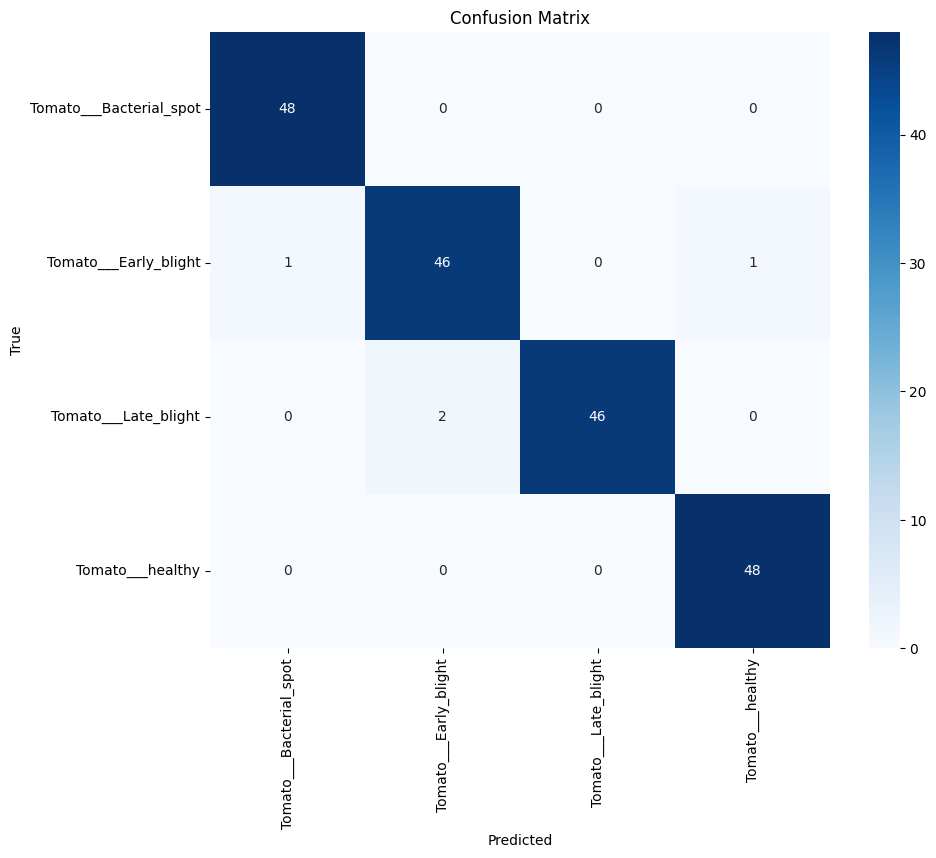

In [27]:
evaluate_client(client_model, test_loader, client_classes)

In [28]:
CLIENT_NAME = "Client 2"
CLIENT_DIR = "/content/drive/MyDrive/clients_datasets/client_2"
SAVE_DIR   = "/content/drive/MyDrive/clients_models"
os.makedirs(SAVE_DIR, exist_ok=True)

In [29]:
train_loader, val_loader, test_loader, client_classes = load_client_data(CLIENT_DIR, batch_size=32, use_sampler=True)
print(f"{CLIENT_NAME} Classes:", client_classes)

Client 2 Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [30]:
num_classes = len(client_classes)
client_model = MobileNetStudent(num_classes)
client_model = client_model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [31]:
history = train_one_client(
    model=client_model,
    train_loader=train_loader,
    val_loader=val_loader,
    client_name=CLIENT_NAME,
    epochs=5,      # change as needed
    lr=1e-4
)


[Client 2] Epoch 1/5


Train Loss: 0.4539 | Train Acc: 0.8730 | Val Loss: 0.1641 | Val Acc: 0.9480

[Client 2] Epoch 2/5


Train Loss: 0.1236 | Train Acc: 0.9627 | Val Loss: 0.0956 | Val Acc: 0.9693

[Client 2] Epoch 3/5


Train Loss: 0.0796 | Train Acc: 0.9787 | Val Loss: 0.0871 | Val Acc: 0.9687

[Client 2] Epoch 4/5


Train Loss: 0.0488 | Train Acc: 0.9861 | Val Loss: 0.0797 | Val Acc: 0.9727

[Client 2] Epoch 5/5


Train Loss: 0.0470 | Train Acc: 0.9839 | Val Loss: 0.0647 | Val Acc: 0.9820


In [32]:
torch.save(client_model.state_dict(), f"{SAVE_DIR}/client2_mobilenet.pth")
torch.save(history, f"{SAVE_DIR}/client2_history.pt")
print(f"{CLIENT_NAME} model & history saved at {SAVE_DIR}")

Client 2 model & history saved at /content/drive/MyDrive/clients_models



Test Accuracy: 97.53%

Classification Report:
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot     0.9739    0.9933    0.9835       150
                        Tomato___Early_blight     0.9929    0.9333    0.9622       150
                         Tomato___Late_blight     0.9494    1.0000    0.9740       150
                           Tomato___Leaf_Mold     1.0000    0.9467    0.9726       150
                  Tomato___Septoria_leaf_spot     0.9597    0.9533    0.9565       150
Tomato___Spider_mites Two-spotted_spider_mite     0.9732    0.9667    0.9699       150
                         Tomato___Target_Spot     0.9250    0.9867    0.9548       150
       Tomato___Tomato_Yellow_Leaf_Curl_Virus     1.0000    0.9933    0.9967       150
                 Tomato___Tomato_mosaic_virus     0.9868    1.0000    0.9934       150
                             Tomato___healthy     1.0000    0.9800    0.9899      

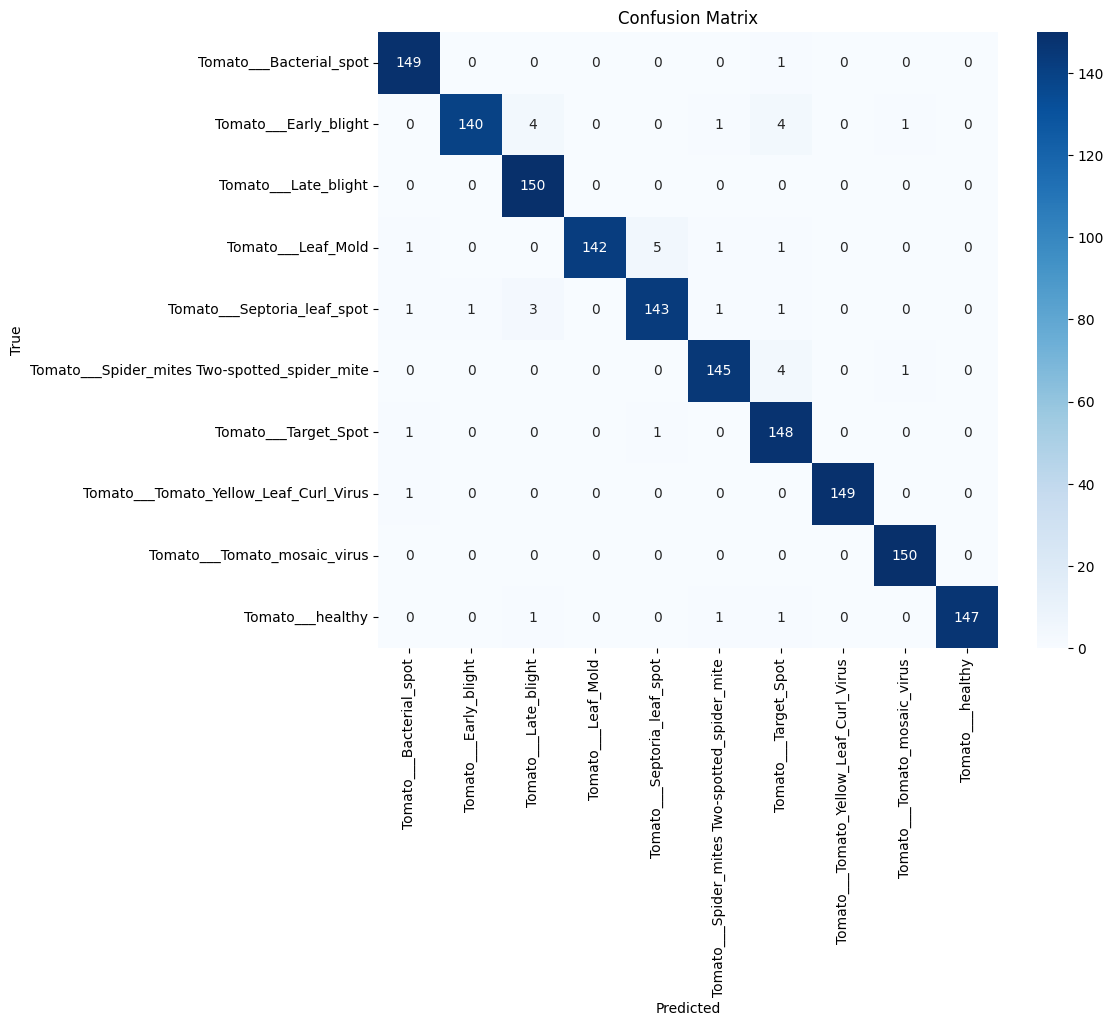

In [33]:
evaluate_client(client_model, test_loader, client_classes)

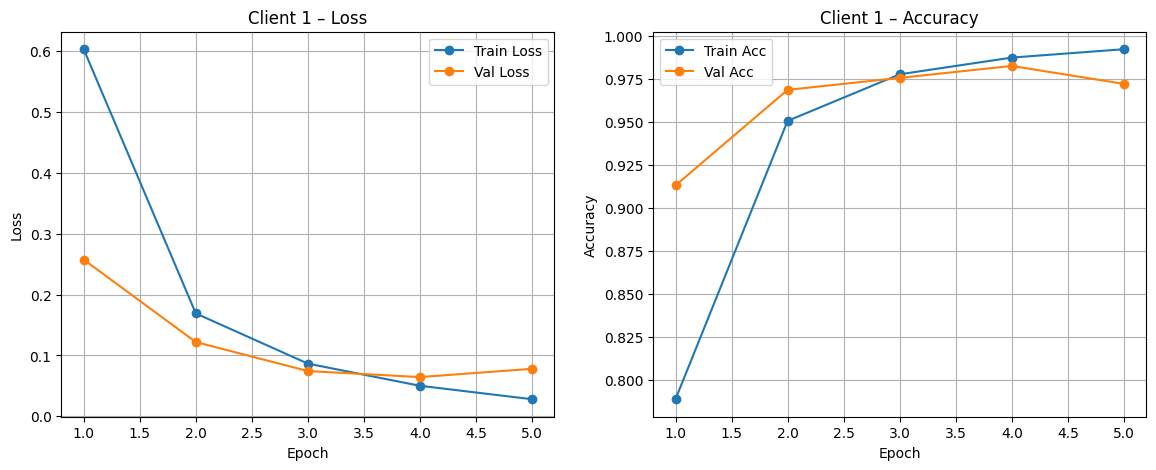

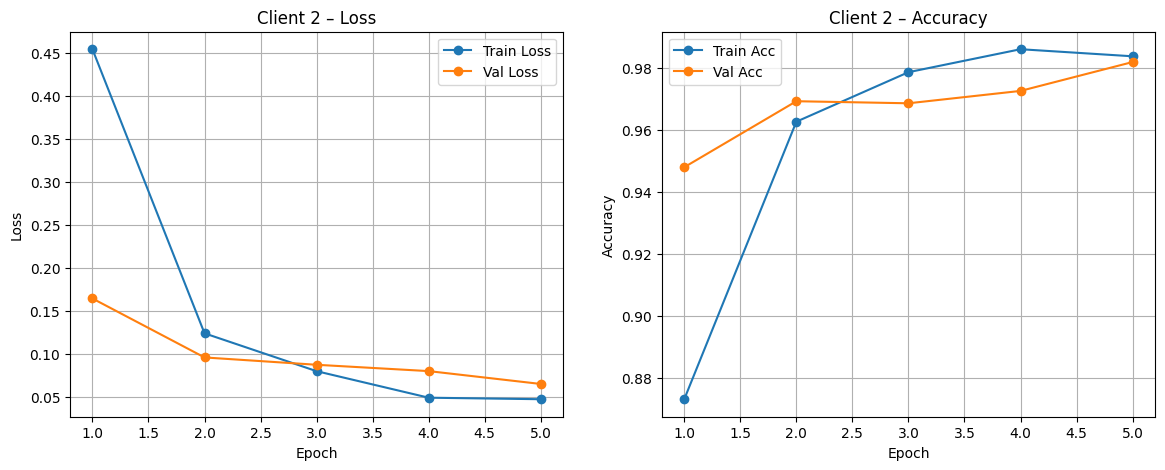

In [34]:
# ================= LOAD HISTORIES =================
# Example paths, replace with your saved histories
client1_history_path = "/content/drive/MyDrive/clients_models/client1_history.pt"
client2_history_path = "/content/drive/MyDrive/clients_models/client2_history.pt"

history1 = torch.load(client1_history_path)
history2 = torch.load(client2_history_path)

# ================= PLOT FUNCTION =================
def plot_client_curves(history, client_name):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14,5))

    # ----- Loss -----
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], marker='o', label='Train Loss')
    plt.plot(epochs, history['val_loss'], marker='o', label='Val Loss')
    plt.title(f"{client_name} – Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    # ----- Accuracy -----
    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_acc'], marker='o', label='Train Acc')
    plt.plot(epochs, history['val_acc'], marker='o', label='Val Acc')
    plt.title(f"{client_name} – Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.show()

# ================= PLOT FOR BOTH CLIENTS =================
plot_client_curves(history1, "Client 1")
plot_client_curves(history2, "Client 2")

In [35]:
import torch
import pandas as pd

client1_hist = torch.load(
    "/content/drive/MyDrive/clients_models/client1_history.pt",
    map_location="cpu"
)

client2_hist = torch.load(
    "/content/drive/MyDrive/clients_models/client2_history.pt",
    map_location="cpu"
)

In [36]:
def extract_final_metrics(history):
    return {
        "Train Acc": history["train_acc"][-1],
        "Val Acc": history["val_acc"][-1],
        "Train Loss": history["train_loss"][-1],
        "Val Loss": history["val_loss"][-1],
    }

In [37]:
client1_test_acc = 97.92   # float
client2_test_acc = 97.53  # float

In [38]:
client1_metrics = extract_final_metrics(client1_hist)
client2_metrics = extract_final_metrics(client2_hist)

results_table = pd.DataFrame(
    [
        {
            "Client": "Client-1",
            **client1_metrics,
            "Test Acc": client1_test_acc
        },
        {
            "Client": "Client-2",
            **client2_metrics,
            "Test Acc": client2_test_acc
        }
    ]
)

results_table

,Client,Train Acc,Val Acc,Train Loss,Val Loss,Test Acc
0,Client-1,0.992361,0.972222,0.028148,0.078111,97.92
1,Client-2,0.983857,0.982000,0.047005,0.064743,97.53


In [39]:
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision.datasets import ImageFolder
from torchvision import transforms
# ================== LOAD CLIENT MODEL ==================
from torch.utils.data import WeightedRandomSampler

def load_client_data(client_dir, batch_size=32, use_sampler=True):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    train_ds = ImageFolder(client_dir + "/train", transform=transform)
    val_ds   = ImageFolder(client_dir + "/val", transform=transform)
    test_ds  = ImageFolder(client_dir + "/test", transform=transform)

    # ------------------------------
    # Class-balanced sampler
    # ------------------------------
    if use_sampler:
        class_counts = [0] * len(train_ds.classes)
        for _, label in train_ds.samples:
            class_counts[label] += 1

        MAX_WEIGHT = 5.0
        sample_weights = [min(1.0 / class_counts[label] if class_counts[label] > 0 else 1.0, MAX_WEIGHT)
                          for _, label in train_ds.samples]

        train_sampler = WeightedRandomSampler(
            sample_weights, num_samples=len(sample_weights), replacement=True
        )
        train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=train_sampler)
    else:
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, train_ds.classes


In [40]:
# ================== EXTRACT CLIENT PROTOTYPES ==================
def extract_client_prototypes(model, dataset_dir, batch_size=32):
    """
    Extract class-wise embeddings for KD
    """
    train_loader, _, _, classes = load_client_data(dataset_dir, batch_size=batch_size)
    model.eval()
    feature_extractor = nn.Sequential(*list(model.model.children())[:-1])  # everything except classifier
    feature_extractor.to(device)
    class_embeddings = {cls: [] for cls in classes}

    with torch.no_grad():
        for imgs, labels in tqdm(train_loader, desc="Extracting embeddings"):
            imgs, labels = imgs.to(device), labels.to(device)
            feats = feature_extractor(imgs)
            feats = feats.view(feats.size(0), -1)
            feats = F.normalize(feats, dim=1)  # normalize embedding
            for i, lbl in enumerate(labels):
                class_embeddings[classes[lbl]].append(feats[i].cpu().numpy())

    # Compute mean embedding per class
    prototypes = {}
    for cls in classes:
        prototypes[cls] = np.mean(np.stack(class_embeddings[cls]), axis=0)

    return prototypes, classes

In [41]:
# ================== NORMALIZE CLASS NAMES ==================
def normalize_class_names(prototypes_dicts):
    """
    prototypes_dicts: list of dicts from clients
    Returns: normalized dict mapping global class names -> list of embeddings
    """
    global_classes = set()
    for p in prototypes_dicts:
        global_classes.update(p.keys())
    global_classes = sorted(list(global_classes))

    normalized = {cls: [] for cls in global_classes}
    for p in prototypes_dicts:
        for cls in global_classes:
            if cls in p:
                normalized[cls].append(p[cls])
    return normalized, global_classes

In [42]:
# ================== AGGREGATE GLOBAL PROTOTYPES ==================
def aggregate_global_prototypes(normalized_dict):
    """
    For each class, average all client prototypes
    """
    global_prototypes = {}
    for cls, embeds in normalized_dict.items():
        global_prototypes[cls] = np.mean(np.stack(embeds), axis=0)
    return global_prototypes

In [43]:
# ================== LOAD CLIENT 1 DATA ==================
CLIENT1_DIR = "/content/drive/MyDrive/clients_datasets/client_1"

# Load data loaders and classes
train_loader_client1, val_loader_client1, test_loader_client1, client1_classes = load_client_data(CLIENT1_DIR, batch_size=32)

print("Client 1 Classes:", client1_classes)

Client 1 Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']


In [44]:
# Initialize student model for Client 1
client1_model = MobileNetStudent(num_classes=len(client1_classes))

# Load trained checkpoint if exists
checkpoint_path = "/content/drive/MyDrive/clients_models/client1_mobilenet.pth"  # path
if os.path.exists(checkpoint_path):
    client1_model = load_client_model(client1_model, checkpoint_path)
else:
    print("Client 1 model not found. You need to train it first.")

Client model loaded from /content/drive/MyDrive/clients_models/client1_mobilenet.pth safely on cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [45]:
CLIENT2_DIR = "/content/drive/MyDrive/clients_datasets/client_2"

In [46]:
import torch.nn.functional as F

# ---------------- CLIENT 1 ----------------
train_loader1, val_loader1, test_loader1, client1_classes = load_client_data(CLIENT1_DIR)

client1_model = MobileNetStudent(num_classes=len(client1_classes))
client1_model = load_client_model(client1_model, "/content/drive/MyDrive/clients_models/client1_mobilenet.pth")

# ---------------- CLIENT 2 ----------------
train_loader2, val_loader2, test_loader2, client2_classes = load_client_data(CLIENT2_DIR)

client2_model = MobileNetStudent(num_classes=len(client2_classes))
client2_model = load_client_model(client2_model, "/content/drive/MyDrive/clients_models/client2_mobilenet.pth")

# ---------------- EXTRACT & AGGREGATE ----------------
proto1, classes1 = extract_client_prototypes(client1_model, CLIENT1_DIR)
proto2, classes2 = extract_client_prototypes(client2_model, CLIENT2_DIR)

# Normalize class names
normalized_dict, global_classes = normalize_class_names([proto1, proto2])

# Aggregate global prototypes
global_prototypes = aggregate_global_prototypes(normalized_dict)

Client model loaded from /content/drive/MyDrive/clients_models/client1_mobilenet.pth safely on cuda
Client model loaded from /content/drive/MyDrive/clients_models/client2_mobilenet.pth safely on cuda


Extracting embeddings: 100%|██████████| 219/219 [00:47<00:00,  4.64it/s]


In [47]:
# Assuming your embeddings are in dictionaries like:
# proto1, proto2
# proto1 = {'tomato_early_blight': tensor(...), ...}

import torch

# Save Client 1 embeddings
torch.save(proto1, "/content/client1_prototypes.pt")
# Save Client 2 embeddings
torch.save(proto2, "/content/client2_prototypes.pt")

print("Embeddings saved successfully!")

Embeddings saved successfully!


In [48]:
from google.colab import files

# Download Client 1
files.download("/content/client1_prototypes.pt")
# Download Client 2
files.download("/content/client2_prototypes.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import re

device = "cuda" if torch.cuda.is_available() else "cpu"

**Normalization of Class Names**

In [50]:
import re

def normalize_class_name(name):
    name = name.lower()

    # remove tomato prefix
    name = re.sub(r"^tomato[_ ]+", "", name)
    name = name.replace("tomato___", "")
    name = name.replace("tomato__", "")
    name = name.replace("tomato_", "")

    # unify separators
    name = name.replace("-", "_")
    name = name.replace(" ", "_")

    # FIX KNOWN DATASET INCONSISTENCIES
    name = name.replace("two_spotted", "twospotted")
    name = name.replace("two_spotted_spider_mite", "twospotted_spider_mite")
    name = name.replace("two_spotted_spider_mites", "twospotted_spider_mite")
    name = name.replace("spider_mites_twospotted", "spider_mites_twospotted")

    # cleanup
    name = re.sub(r"[^a-z0-9_]", "", name)
    name = re.sub(r"_+", "_", name)

    return name.strip("_")

**Loading Teacher Prototypes**

In [51]:
teacher_prototypes = torch.load(
    "/content/drive/MyDrive/teacher_prototypes.pt",
    weights_only=False
)

teacher_prototypes = {
    normalize_class_name(k): v.to(device)
    for k, v in teacher_prototypes.items()
}

print("Teacher classes:")
for k in teacher_prototypes.keys():
    print(k)

Teacher classes:
bacterial_spot
yellow_leaf_curl_virus
spotted_wilt_virus
leaf_miner
target_spot
spider_mites
potassium_deficiency
early_blight
late_blight
septoria_leaf_spot
leaf_mold
mosaic_virus
nitrogen_deficiency
magnesium_deficiency
powdery_mildew
healthy


In [52]:
def resolve_teacher_class(norm_cls, teacher_keys):
    """
    Maps fine-grained client class → coarse teacher class
    """

    # Exact match
    if norm_cls in teacher_keys:
        return norm_cls

    # Spider mites family
    if "spider_mite" in norm_cls or "spider_mites" in norm_cls:
        return "spider_mites"

    # Virus family
    if "yellow_leaf_curl" in norm_cls:
        return "yellow_leaf_curl_virus"

    if "mosaic" in norm_cls:
        return "mosaic_virus"

    # Default: no mapping
    return None

**Loading Client Datasets**

In [53]:
train_loader1, val_loader1, test_loader1, client1_classes = load_client_data(CLIENT1_DIR)
train_loader2, val_loader2, test_loader2, client2_classes = load_client_data(CLIENT2_DIR)

**Client-Teacher Class Map**

In [54]:
client1_class_map = {}

for cls in client1_classes:
    norm_cls = normalize_class_name(cls)

    if norm_cls in teacher_prototypes:
        client1_class_map[cls] = norm_cls
    else:
        raise KeyError(f"[Client-1] Class not found in teacher: {cls}")

print("Client-1 class mapping:")
for k, v in client1_class_map.items():
    print(f"{k} → {v}")

Client-1 class mapping:
Tomato___Bacterial_spot → bacterial_spot
Tomato___Early_blight → early_blight
Tomato___Late_blight → late_blight
Tomato___healthy → healthy


In [55]:
client2_class_map = {}

print("\nClient-2 → Teacher mapping:\n")

for cls in client2_classes:
    norm_cls = normalize_class_name(cls)
    resolved = resolve_teacher_class(norm_cls, teacher_prototypes.keys())

    print(f"{cls}")
    print(f" → normalized: {norm_cls}")

    if resolved is not None:
        client2_class_map[cls] = resolved
        print(f" → mapped to teacher: {resolved}\n")
    else:
        raise KeyError(f"[Client-2] No teacher mapping for class: {cls}")



Client-2 → Teacher mapping:

Tomato___Bacterial_spot
 → normalized: bacterial_spot
 → mapped to teacher: bacterial_spot

Tomato___Early_blight
 → normalized: early_blight
 → mapped to teacher: early_blight

Tomato___Late_blight
 → normalized: late_blight
 → mapped to teacher: late_blight

Tomato___Leaf_Mold
 → normalized: leaf_mold
 → mapped to teacher: leaf_mold

Tomato___Septoria_leaf_spot
 → normalized: septoria_leaf_spot
 → mapped to teacher: septoria_leaf_spot

Tomato___Spider_mites Two-spotted_spider_mite
 → normalized: spider_mites_twospotted_spider_mite
 → mapped to teacher: spider_mites

Tomato___Target_Spot
 → normalized: target_spot
 → mapped to teacher: target_spot

Tomato___Tomato_Yellow_Leaf_Curl_Virus
 → normalized: yellow_leaf_curl_virus
 → mapped to teacher: yellow_leaf_curl_virus

Tomato___Tomato_mosaic_virus
 → normalized: mosaic_virus
 → mapped to teacher: mosaic_virus

Tomato___healthy
 → normalized: healthy
 → mapped to teacher: healthy



**Student Model**

In [56]:
from torchvision.models import mobilenet_v2

class MobileNetStudent(nn.Module):
    def __init__(self, num_classes, teacher_dim=1408):
        super().__init__()

        self.backbone = mobilenet_v2(weights="IMAGENET1K_V1")
        self.backbone.classifier = nn.Identity()

        self.student_dim = 1280
        self.teacher_dim = teacher_dim

        self.kd_proj = nn.Linear(self.student_dim, self.teacher_dim)
        self.classifier = nn.Linear(self.student_dim, num_classes)

    def forward(self, x, return_features=False):
        feat = self.backbone(x)
        logits = self.classifier(feat)

        if return_features:
            kd_feat = self.kd_proj(feat)
            return logits, kd_feat

        return logits

**Loss Calculation**

In [57]:
ce_loss = nn.CrossEntropyLoss()
mse_loss = nn.MSELoss()

**KD Training Function**

In [65]:
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Loss functions
ce_loss = nn.CrossEntropyLoss()
mse_loss = nn.MSELoss()

def train_client_with_kd(
    student_model,
    train_loader,
    val_loader,
    student_classes,
    class_map,
    teacher_prototypes,
    client_name="Client",
    epochs=5,
    alpha=0.85,          # CE weight
    lr=1e-4
):
    """
    Train a student model on a client with Knowledge Distillation (feature-level).
    """
    optimizer = optim.Adam(student_model.parameters(), lr=lr)
    student_model.to(device)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    kd_epochs = epochs // 2        # KD only in early epochs
    kd_weight = 0.3               # weaken feature KD

    for epoch in range(epochs):
        student_model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        print(f"\n[{client_name}] Epoch {epoch+1}/{epochs}")

        train_bar = tqdm(
            train_loader,
            desc=f"[{client_name}] Training",
            leave=False
        )

        for imgs, labels in train_bar:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()

            # Forward pass
            logits, student_kd_feat = student_model(imgs, return_features=True)

            # Cross-entropy loss
            loss_ce = ce_loss(logits, labels)

            # Build teacher prototype batch
            teacher_batch = torch.stack([
                teacher_prototypes[class_map[student_classes[l.item()]]]
                for l in labels
            ]).to(device)

            # Normalize features (important)
            student_kd_feat = F.normalize(student_kd_feat, dim=1)
            teacher_batch = F.normalize(teacher_batch, dim=1)

            # Feature KD loss
            loss_kd = mse_loss(student_kd_feat, teacher_batch)

            # Corrected total loss
            if epoch < kd_epochs:
                loss = alpha * loss_ce + (1 - alpha) * kd_weight * loss_kd
            else:
                loss = loss_ce

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(logits, 1)
            running_correct += (preds == labels).sum().item()
            running_total += labels.size(0)

            train_bar.set_postfix({
                "loss": f"{running_loss / running_total:.4f}",
                "acc": f"{running_correct / running_total:.4f}"
            })

        avg_train_loss = running_loss / running_total
        avg_train_acc = running_correct / running_total

        history["train_loss"].append(avg_train_loss)
        history["train_acc"].append(avg_train_acc)

        # ----------------- Validation -----------------
        student_model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        val_bar = tqdm(
            val_loader,
            desc=f"[{client_name}] Validation",
            leave=False
        )

        with torch.no_grad():
            for imgs, labels in val_bar:
                imgs, labels = imgs.to(device), labels.to(device)
                logits = student_model(imgs)

                loss = ce_loss(logits, labels)
                val_loss += loss.item() * imgs.size(0)

                preds = logits.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

                val_bar.set_postfix({
                    "loss": f"{val_loss / val_total:.4f}",
                    "acc": f"{val_correct / val_total:.4f}"
                })

        avg_val_loss = val_loss / val_total
        avg_val_acc = val_correct / val_total

        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(avg_val_acc)

        print(
            f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f}"
        )

    return history

**Training Client 1**

In [67]:
client1_model_kd = MobileNetStudent(num_classes=len(client1_classes))

kd_history_client1 = train_client_with_kd(
    student_model=client1_model_kd,
    train_loader=train_loader1,
    val_loader=val_loader1,
    student_classes=client1_classes,
    class_map=client1_class_map,
    teacher_prototypes=teacher_prototypes,
    client_name="Client-1",
    epochs=10,
    alpha=0.85
)

torch.save(
    client1_model_kd.state_dict(),
    "/content/drive/MyDrive/clients_models/client1_model_kd.pth"
)


[Client-1] Epoch 1/10


Train Loss: 0.4881 | Train Acc: 0.8132 | Val Loss: 0.3166 | Val Acc: 0.8889

[Client-1] Epoch 2/10


Train Loss: 0.1196 | Train Acc: 0.9549 | Val Loss: 0.0985 | Val Acc: 0.9757

[Client-1] Epoch 3/10


Train Loss: 0.0549 | Train Acc: 0.9847 | Val Loss: 0.0802 | Val Acc: 0.9722

[Client-1] Epoch 4/10


Train Loss: 0.0408 | Train Acc: 0.9861 | Val Loss: 0.0746 | Val Acc: 0.9757

[Client-1] Epoch 5/10


...

Train Loss: 0.0113 | Train Acc: 0.9986 | Val Loss: 0.0517 | Val Acc: 0.9826

[Client-1] Epoch 7/10


Train Loss: 0.0190 | Train Acc: 0.9931 | Val Loss: 0.0573 | Val Acc: 0.9792

[Client-1] Epoch 8/10


Train Loss: 0.0137 | Train Acc: 0.9972 | Val Loss: 0.0882 | Val Acc: 0.9653

[Client-1] Epoch 9/10


Train Loss: 0.0164 | Train Acc: 0.9951 | Val Loss: 0.0694 | Val Acc: 0.9722

[Client-1] Epoch 10/10


Train Loss: 0.0119 | Train Acc: 0.9965 | Val Loss: 0.0682 | Val Acc: 0.9792


In [68]:
torch.save(client1_model_kd.state_dict(), "/content/drive/MyDrive/clients_models/client1_model_kd.pth")

In [69]:
baseline_history = torch.load(
    "/content/drive/MyDrive/clients_models/client1_history.pt"
)

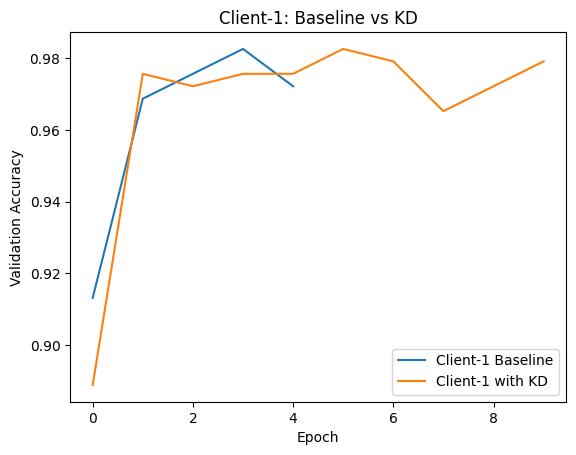

In [70]:
import matplotlib.pyplot as plt

plt.plot(baseline_history["val_acc"], label="Client-1 Baseline")
plt.plot(kd_history_client1["val_acc"], label="Client-1 with KD")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("Client-1: Baseline vs KD")
plt.show()

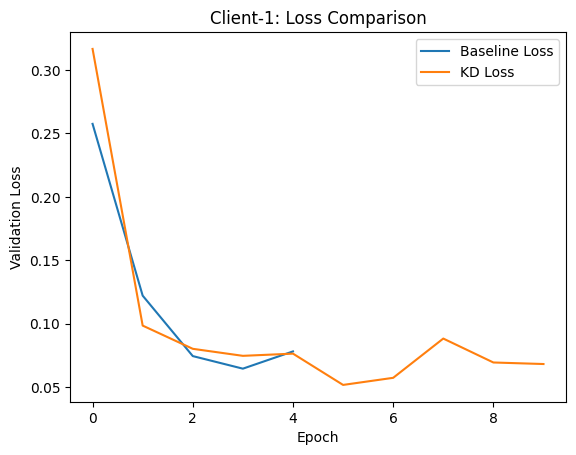

In [71]:
plt.plot(baseline_history["val_loss"], label="Baseline Loss")
plt.plot(kd_history_client1["val_loss"], label="KD Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.title("Client-1: Loss Comparison")
plt.show()

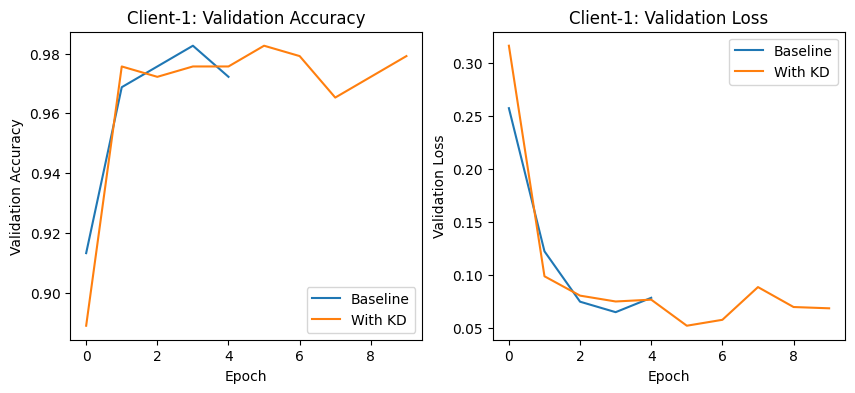

Client-1 Test Accuracy (KD): 0.9531

Class-wise Accuracy:
Tomato___Bacterial_spot: 0.9375
Tomato___Early_blight: 0.8750
Tomato___Late_blight: 1.0000
Tomato___healthy: 1.0000

Classification Report:
                         precision    recall  f1-score   support

Tomato___Bacterial_spot       0.98      0.94      0.96        48
  Tomato___Early_blight       0.93      0.88      0.90        48
   Tomato___Late_blight       0.92      1.00      0.96        48
       Tomato___healthy       0.98      1.00      0.99        48

               accuracy                           0.95       192
              macro avg       0.95      0.95      0.95       192
           weighted avg       0.95      0.95      0.95       192



In [72]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ----------------------------
#  Load baseline history
# ----------------------------
baseline_history = torch.load("/content/drive/MyDrive/clients_models/client1_history.pt")

# ----------------------------
#  Plot validation accuracy
# ----------------------------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(baseline_history["val_acc"], label="Baseline")
plt.plot(kd_history_client1["val_acc"], label="With KD")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Client-1: Validation Accuracy")
plt.legend()

# ----------------------------
# Plot validation loss
# ----------------------------
plt.subplot(1,2,2)
plt.plot(baseline_history["val_loss"], label="Baseline")
plt.plot(kd_history_client1["val_loss"], label="With KD")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Client-1: Validation Loss")
plt.legend()
plt.show()

# ----------------------------
#  Evaluate KD-trained model on test set
# ----------------------------
student_model = client1_model_kd  # KD-trained model
student_model.eval()
student_model.to(device)

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader1:
        images, labels = images.to(device), labels.to(device)
        logits = student_model(images)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_labels = torch.tensor(all_labels)
all_preds = torch.tensor(all_preds)

# ----------------------------
#  Overall test accuracy
# ----------------------------
test_acc = (all_preds == all_labels).sum().item() / len(all_labels)
print(f"Client-1 Test Accuracy (KD): {test_acc:.4f}")

# ----------------------------
#  Class-wise accuracy
# ----------------------------
num_classes = len(client1_classes)
class_correct = [0] * num_classes
class_total = [0] * num_classes

for label, pred in zip(all_labels, all_preds):
    class_total[label] += 1
    if label == pred:
        class_correct[label] += 1

print("\nClass-wise Accuracy:")
for idx, cls_name in enumerate(client1_classes):
    acc = class_correct[idx] / class_total[idx] if class_total[idx] > 0 else 0
    print(f"{cls_name}: {acc:.4f}")

# ----------------------------
#  Classification report
# ----------------------------
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=client1_classes))

In [73]:
from sklearn.metrics import classification_report
import pandas as pd
import torch

def evaluate_model(model, test_loader, class_names, device):
    model.eval()
    model.to(device)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = torch.tensor(all_preds)
    all_labels = torch.tensor(all_labels)

    # Overall accuracy
    acc = (all_preds == all_labels).sum().item() / len(all_labels)

    # Class-wise accuracy
    class_correct = [0] * len(class_names)
    class_total = [0] * len(class_names)

    for y, p in zip(all_labels, all_preds):
        class_total[y] += 1
        if y == p:
            class_correct[y] += 1

    class_acc = {
        class_names[i]: (class_correct[i] / class_total[i] if class_total[i] > 0 else 0)
        for i in range(len(class_names))
    }

    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        output_dict=True
    )

    return acc, class_acc, report


In [74]:
from torchvision.models import mobilenet_v2

def build_mobilenet(num_classes):
    model = mobilenet_v2(weights=None)
    model.classifier[1] = torch.nn.Linear(
        model.classifier[1].in_features,
        num_classes
    )
    return model

In [75]:
def load_baseline_mobilenet(model, checkpoint_path, device):
    state_dict = torch.load(checkpoint_path, map_location=device)

    new_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith("model."):
            new_state_dict[k[len("model."):]] = v
        else:
            new_state_dict[k] = v

    model.load_state_dict(new_state_dict, strict=True)
    model.to(device)
    model.eval()

    print(" Baseline MobileNet loaded successfully")
    return model

**Client 2 KD Training**

In [80]:
client2_model_kd = MobileNetStudent(num_classes=len(client2_classes))

kd_history_client2 = train_client_with_kd(
    student_model=client2_model_kd,
    train_loader=train_loader2,
    val_loader=val_loader2,
    student_classes=client2_classes,
    class_map=client2_class_map,
    teacher_prototypes=teacher_prototypes,
    client_name="Client-2",
    epochs=10,
    alpha=0.85
)

torch.save(
    client1_model_kd.state_dict(),
    "/content/drive/MyDrive/clients_models/client1_model_kd.pth"
)


[Client-2] Epoch 1/10


Train Loss: 0.3629 | Train Acc: 0.8807 | Val Loss: 0.1364 | Val Acc: 0.9627

[Client-2] Epoch 2/10


Train Loss: 0.0878 | Train Acc: 0.9700 | Val Loss: 0.0984 | Val Acc: 0.9647

[Client-2] Epoch 3/10


Train Loss: 0.0486 | Train Acc: 0.9834 | Val Loss: 0.0758 | Val Acc: 0.9740

[Client-2] Epoch 4/10


Train Loss: 0.0264 | Train Acc: 0.9917 | Val Loss: 0.0680 | Val Acc: 0.9800

[Client-2] Epoch 5/10


...

Train Loss: 0.0331 | Train Acc: 0.9909 | Val Loss: 0.0788 | Val Acc: 0.9753

[Client-2] Epoch 7/10


Train Loss: 0.0337 | Train Acc: 0.9894 | Val Loss: 0.0748 | Val Acc: 0.9760

[Client-2] Epoch 8/10


Train Loss: 0.0175 | Train Acc: 0.9959 | Val Loss: 0.0580 | Val Acc: 0.9827

[Client-2] Epoch 9/10


Train Loss: 0.0182 | Train Acc: 0.9950 | Val Loss: 0.0853 | Val Acc: 0.9740

[Client-2] Epoch 10/10


Train Loss: 0.0210 | Train Acc: 0.9930 | Val Loss: 0.0853 | Val Acc: 0.9740


In [81]:
torch.save(client2_model_kd.state_dict(), "/content/drive/MyDrive/clients_models/client2_model_kd.pth")

In [82]:
baseline_history = torch.load(
    "/content/drive/MyDrive/clients_models/client2_history.pt"
)

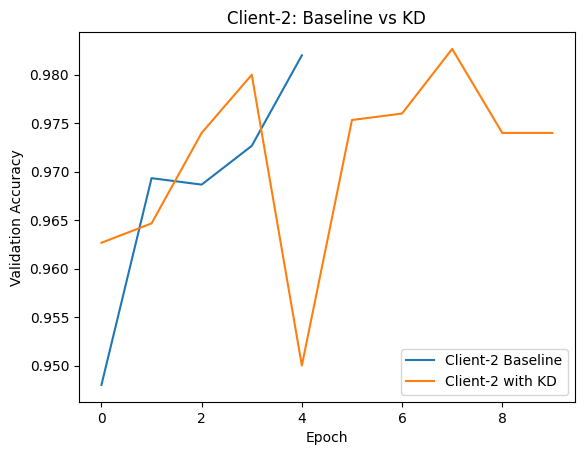

In [83]:
import matplotlib.pyplot as plt

plt.plot(baseline_history["val_acc"], label="Client-2 Baseline")
plt.plot(kd_history_client2["val_acc"], label="Client-2 with KD")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("Client-2: Baseline vs KD")
plt.show()

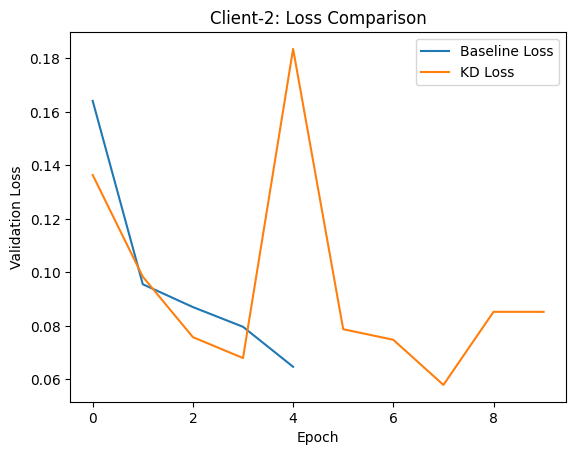

In [84]:
plt.plot(baseline_history["val_loss"], label="Baseline Loss")
plt.plot(kd_history_client2["val_loss"], label="KD Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.title("Client-2: Loss Comparison")
plt.show()

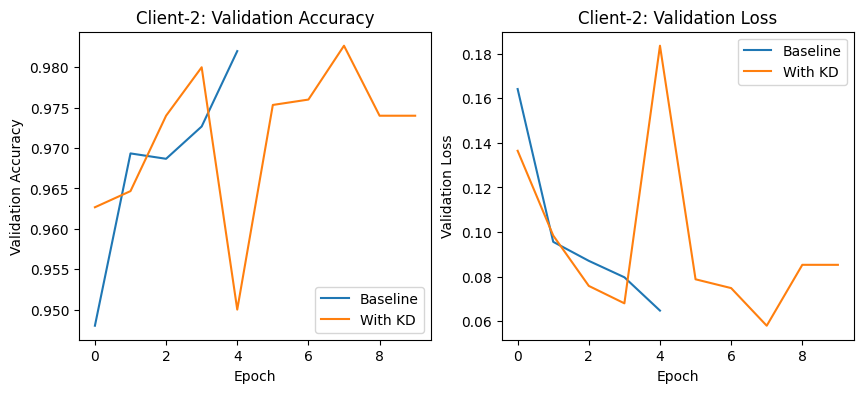

Client-2 Test Accuracy (KD): 0.9813

Class-wise Accuracy:
Tomato___Bacterial_spot: 0.9933
Tomato___Early_blight: 0.9000
Tomato___Late_blight: 0.9933
Tomato___Leaf_Mold: 0.9933
Tomato___Septoria_leaf_spot: 0.9600
Tomato___Spider_mites Two-spotted_spider_mite: 0.9867
Tomato___Target_Spot: 0.9933
Tomato___Tomato_Yellow_Leaf_Curl_Virus: 0.9933
Tomato___Tomato_mosaic_virus: 1.0000
Tomato___healthy: 1.0000

Classification Report:
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.97      0.99      0.98       150
                        Tomato___Early_blight       1.00      0.90      0.95       150
                         Tomato___Late_blight       0.93      0.99      0.96       150
                           Tomato___Leaf_Mold       0.99      0.99      0.99       150
                  Tomato___Septoria_leaf_spot       0.97      0.96      0.96       150
Tomato___Spider_mites Two-spotted_spider_mite    

In [85]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ----------------------------
#  Load baseline history
# ----------------------------
baseline_history = torch.load("/content/drive/MyDrive/clients_models/client2_history.pt")

# ----------------------------
#  Plot validation accuracy
# ----------------------------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(baseline_history["val_acc"], label="Baseline")
plt.plot(kd_history_client2["val_acc"], label="With KD")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Client-2: Validation Accuracy")
plt.legend()

# ----------------------------
# Plot validation loss
# ----------------------------
plt.subplot(1,2,2)
plt.plot(baseline_history["val_loss"], label="Baseline")
plt.plot(kd_history_client2["val_loss"], label="With KD")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Client-2: Validation Loss")
plt.legend()
plt.show()

# ----------------------------
#  Evaluate KD-trained model on test set
# ----------------------------
student_model = client2_model_kd  # KD-trained model
student_model.eval()
student_model.to(device)

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader2:
        images, labels = images.to(device), labels.to(device)
        logits = student_model(images)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_labels = torch.tensor(all_labels)
all_preds = torch.tensor(all_preds)

# ----------------------------
#  Overall test accuracy
# ----------------------------
test_acc = (all_preds == all_labels).sum().item() / len(all_labels)
print(f"Client-2 Test Accuracy (KD): {test_acc:.4f}")

# ----------------------------
#  Class-wise accuracy
# ----------------------------
num_classes = len(client2_classes)
class_correct = [0] * num_classes
class_total = [0] * num_classes

for label, pred in zip(all_labels, all_preds):
    class_total[label] += 1
    if label == pred:
        class_correct[label] += 1

print("\nClass-wise Accuracy:")
for idx, cls_name in enumerate(client2_classes):
    acc = class_correct[idx] / class_total[idx] if class_total[idx] > 0 else 0
    print(f"{cls_name}: {acc:.4f}")

# ----------------------------
#  Classification report
# ----------------------------
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=client2_classes))

**Summary Table**

In [86]:
import pandas as pd
import numpy as np

clients_data = [
    {
        "client": "Client-1",
        "num_classes": 4,
        "test_acc_before_kd": 0.9792,  # replace with actual
        "test_acc_after_kd": 0.9531,
        "class_wise_acc": {
            "Tomato___Bacterial_spot": 0.9375,
            "Tomato___Early_blight": 0.8750,
            "Tomato___Late_blight": 1.0,
            "Tomato___healthy": 1.0
        }
    },
    {
        "client": "Client-2",
        "num_classes": 10,
        "test_acc_before_kd": 0.9753,  # replace with actual
        "test_acc_after_kd": 0.9813,
        "class_wise_acc": {
            "Tomato___Bacterial_spot": 0.9933,
            "Tomato___Early_blight": 0.9000,
            "Tomato___Late_blight": 0.9933,
            "Tomato___Leaf_Mold": 0.9933,
            "Tomato___Septoria_leaf_spot": 0.9600,
            "Tomato___Spider_mites Two-spotted_spider_mite": 0.9867,
            "Tomato___Target_Spot": 0.9933,
            "Tomato___TYLCV": 0.9933,
            "Tomato___Mosaic_virus": 1.0,
            "Tomato___healthy": 1.0
        }
    }
]

# ---------------------------
# Build summary table
# ---------------------------

summary_rows = []

for client in clients_data:
    before = client["test_acc_before_kd"]
    after = client["test_acc_after_kd"]
    change = after - before if before is not None else np.nan

    summary_rows.append({
        "Client": client["client"],
        "Num Classes": client["num_classes"],
        "Test Acc (Before KD)": before,
        "Test Acc (After KD)": after,
        "Δ Accuracy": change
    })

summary_df = pd.DataFrame(summary_rows)

# Display main summary table
print("\n===== KD Summary Table =====")
print(summary_df)

# Optional: display class-wise accuracy per client
for client in clients_data:
    print(f"\nClass-wise Accuracy for {client['client']}:")
    class_acc_df = pd.DataFrame.from_dict(
        client["class_wise_acc"], orient="index", columns=["Accuracy"]
    )
    print(class_acc_df)



===== KD Summary Table =====
     Client  Num Classes  Test Acc (Before KD)  Test Acc (After KD)  \
0  Client-1            4                0.9792               0.9531   
1  Client-2           10                0.9753               0.9813   

   Δ Accuracy  
0     -0.0261  
1      0.0060  

Class-wise Accuracy for Client-1:
                         Accuracy
Tomato___Bacterial_spot    0.9375
Tomato___Early_blight      0.8750
Tomato___Late_blight       1.0000
Tomato___healthy           1.0000

Class-wise Accuracy for Client-2:
                                               Accuracy
Tomato___Bacterial_spot                          0.9933
Tomato___Early_blight                            0.9000
Tomato___Late_blight                             0.9933
Tomato___Leaf_Mold                               0.9933
Tomato___Septoria_leaf_spot                      0.9600
Tomato___Spider_mites Two-spotted_spider_mite    0.9867
Tomato___Target_Spot                             0.9933
Tomato___TYLCV      